# Lecture 13: Continuous-time heterogeneous agents, numerics

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §8.7 (Numerical methods for CT-HA — partial-equilibrium HJB with discrete income)  
**Notebook role:** core  
**Author:** Simon Scheidegger  

> FP64 + CPU is the intended target. To run on GPU, switch to `torch.float32` (the FD reference solver loses about one digit of accuracy in single precision).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

# Hyperparameters dispatched on RUN_MODE.  The training loop below reads from this block.
if RUN_MODE == "smoke":
    ADAM_EPOCHS = 5_000
    LBFGS_ITERS = 250
    N_COL = 1_000
elif RUN_MODE == "teaching":
    ADAM_EPOCHS = 10_000
    LBFGS_ITERS = 500
    N_COL = 2_000
elif RUN_MODE == "production":
    ADAM_EPOCHS = 30_000
    LBFGS_ITERS = 1_000
    N_COL = 4_000
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")


# Partial Equilibrium HJB with Discrete Income: FD and PINN

## A Stepping-Stone to the Full Aiyagari GE Model

This notebook solves a **partial equilibrium** consumption-savings problem with a
**2-state Markov income chain** in continuous time. We solve the coupled HJB system
using two methods:

1. **Finite Differences (FD)** --- upwind implicit scheme (benchmark)
2. **Physics-Informed Neural Network (PINN)** --- raw PyTorch auto-differentiation

Because prices $(r, w)$ are **exogenous**, there is no general-equilibrium loop.
This makes the problem a clean stepping-stone before tackling the full Aiyagari model
in Notebook 03.

**Notebook path:** `lectures/lecture_13_continuous_time_ha_numerics/code/lecture_13_06_PE_Discrete_HJB_PINN.ipynb`

> **Self-study notebook** \u2014 This is a stepping stone for the in-class Aiyagari notebook (the in-class Aiyagari notebook (Chapter 8.7, the full GE solver)). Work through it before or after class.

## Learning Objectives

- Understand the **coupled HJB system** arising from discrete Markov switching.
- Implement the **upwind finite-difference** scheme for 1D drift-dominated PDEs.
- Build a **PINN** that solves the HJB via auto-differentiation (no grid needed).
- Compare FD and PINN solutions: value functions, policies, and residual diagnostics.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

device = torch.device('cpu')
plt.rcParams['font.size'] = 13
print('Using device:', device)

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


## Model Description

### Household Problem

A household with CRRA preferences maximises lifetime utility over consumption $c_t$:

$$
\max_{c_t} \; \mathbb{E}_0 \int_0^\infty e^{-\rho t} \frac{c_t^{1-\gamma}}{1-\gamma} \, dt
$$

subject to the budget constraint

$$
\dot{a} = r\,a + w\,z - c, \qquad a \ge \underline{a}
$$

where $a$ is wealth, $z \in \{z_L, z_H\}$ is a 2-state Markov income process with
Poisson switching rates $\lambda_{12}$ (from state 1 to 2) and $\lambda_{21}$
(from state 2 to 1), and $(r, w)$ are exogenous prices.

### HJB Equations

In state $j$ the Hamilton-Jacobi-Bellman equation reads:

$$
\rho\,V_j(a) = \max_c \left\{ u(c) + V_j'(a)\,(r\,a + w\,z_j - c) \right\}
              + \sum_{k \ne j} \lambda_{jk}\,(V_k(a) - V_j(a))
$$

### First-Order Condition

The FOC eliminates the max operator:

$$
u'(c) = V_j'(a) \quad\Longrightarrow\quad c_j^*(a) = \bigl(V_j'(a)\bigr)^{-1/\gamma}
$$

Substituting back gives a **coupled system of ODEs** for $(V_1, V_2)$:

$$
\rho\,V_j = u\!\bigl(c_j^*\bigr) + V_j'\,s_j + \lambda_{jk}\,(V_k - V_j),
\qquad s_j = r\,a + w\,z_j - c_j^*
$$

### Boundary Conditions

- **Borrowing constraint** ($a = \underline{a}$): $V_j'(\underline{a}) = u'(\text{income}_j(\underline{a}))$,
  i.e.\ the household consumes its full income ($c = \text{income}$, $s = 0$).
- **Upper bound** ($a = \bar{a}$): same natural condition $V_j'(\bar{a}) = u'(\text{income}_j(\bar{a}))$.

### Parameters

| Symbol | Value | Description |
|--------|-------|-------------|
| $\rho$ | 0.02 | Discount rate |
| $\gamma$ | 2 | CRRA parameter |
| $r$ | 0.01 | Interest rate (PE) |
| $w$ | 1.0 | Wage |
| $z_L, z_H$ | 0.8, 1.2 | Income states |
| $\lambda_{12}, \lambda_{21}$ | 1/3 | Switching rates |
| $\underline{a}, \bar{a}$ | $-1$, $20$ | Wealth bounds |

---

## 1) Finite-Difference Reference Solver

We use the standard **upwind implicit scheme**:

1. Compute forward and backward finite differences of $V$:
   $V_a^F = (V_{i+1}-V_i)/\Delta a$, $\; V_a^B = (V_i-V_{i-1})/\Delta a$.
2. Invert the FOC: $c^F = (V_a^F)^{-1/\gamma}$, $c^B = (V_a^B)^{-1/\gamma}$.
3. Savings candidates: $s^F = \text{income} - c^F$, $s^B = \text{income} - c^B$.
4. **Upwind**: use forward if $s^F > 0$, backward if $s^B < 0$, else $c = \text{income}$.
5. Implicit step:
$$\left(\tfrac{1}{\Delta} + \rho\right) V^{n+1} - A\,V^{n+1} = u(c) + \tfrac{V^n}{\Delta}$$

In [2]:
# ── Economic & grid parameters ──────────────────────────────────
rho   = 0.02
gamma = 2.0
r_pe  = 0.01        # exogenous interest rate (partial equilibrium)
w_pe  = 1.0          # exogenous wage
z_vals = np.array([0.8, 1.2])
lam12 = 1.0 / 3.0
lam21 = 1.0 / 3.0

a_min, a_max = -1.0, 20.0
J = 500              # grid points  (production: 2000)
a_grid = np.linspace(a_min, a_max, J)
da = a_grid[1] - a_grid[0]
n_total = 2 * J      # stacked unknowns [V1; V2]

# Utility helpers (CRRA, gamma=2)
def u_fn(c):
    return c ** (1.0 - gamma) / (1.0 - gamma)

def u_prime(c):
    return c ** (-gamma)

def u_prime_inv(x):
    return x ** (-1.0 / gamma)

# Income at each (state, grid-point): shape [2, J]
income = r_pe * a_grid[None, :] + w_pe * z_vals[:, None]

print(f"Grid: {J} points, a in [{a_min}, {a_max}], da = {da:.4f}")
print(f"Income range state 1: [{income[0,0]:.3f}, {income[0,-1]:.3f}]")
print(f"Income range state 2: [{income[1,0]:.3f}, {income[1,-1]:.3f}]")

Grid: 500 points, a in [-1.0, 20.0], da = 0.0421
Income range state 1: [0.790, 1.000]
Income range state 2: [1.190, 1.400]


In [3]:
# ── Upwind implicit VFI ─────────────────────────────────────────
Delta = 1000.0
maxit = 500
tol   = 1e-8

# Initial guess: perpetuity of consuming current income
V = u_fn(np.maximum(income, 1e-10)) / rho

# Transition generator (Kronecker product for 2-state chain)
Lambda = np.array([[-lam12, lam12], [lam21, -lam21]])
Az = sp.kron(Lambda, sp.eye(J), format='csr')

hjb_history = []

for it in range(maxit):
    # Forward / backward derivatives of V w.r.t. a
    VaF = np.zeros((2, J))
    VaB = np.zeros((2, J))
    VaF[:, :-1] = np.maximum((V[:, 1:] - V[:, :-1]) / da, 1e-8)
    VaB[:, 1:]  = np.maximum((V[:, 1:] - V[:, :-1]) / da, 1e-8)

    # Boundary: V'=u'(income) => c=income, s=0  (natural / borrowing constraint)
    VaF[:, -1] = u_prime(np.maximum(income[:, -1], 1e-10))
    VaB[:,  0] = u_prime(np.maximum(income[:,  0], 1e-10))

    # Consumption from FOC
    cF = u_prime_inv(VaF)
    cB = u_prime_inv(VaB)
    c0 = np.maximum(income, 1e-10)

    # Savings candidates
    sF = income - cF
    sB = income - cB

    # Upwind selection
    IF = (sF > 0).astype(float)
    IB = ((sB < 0) * (1.0 - IF)).astype(float)
    I0 = 1.0 - IF - IB

    c_pol = cF * IF + cB * IB + c0 * I0
    c_pol = np.maximum(c_pol, 1e-10)
    s_pol = sF * IF + sB * IB
    utility = u_fn(c_pol)

    # Sparse drift generator (block-diagonal for 2 states)
    diag0 = (-sF * IF / da + sB * IB / da).reshape(n_total)
    upper = ( sF * IF / da).reshape(n_total)
    lower = (-sB * IB / da).reshape(n_total)

    Aa = (sp.diags(diag0, 0,  shape=(n_total, n_total), format='csr')
        + sp.diags(upper[:-1], 1,  shape=(n_total, n_total), format='csr')
        + sp.diags(lower[1:], -1, shape=(n_total, n_total), format='csr'))

    A = Aa + Az

    # Implicit Bellman step
    B   = (1.0 / Delta + rho) * sp.eye(n_total, format='csr') - A
    rhs = utility.reshape(n_total) + V.reshape(n_total) / Delta
    V_new = spsolve(B, rhs).reshape(2, J)

    dist = np.max(np.abs(V_new - V))
    hjb_history.append(dist)
    V = V_new

    if dist < tol:
        break

# ── Final policies at converged V ───────────────────────────────
VaF_final = np.zeros((2, J))
VaB_final = np.zeros((2, J))
VaF_final[:, :-1] = np.maximum((V[:, 1:] - V[:, :-1]) / da, 1e-8)
VaB_final[:, 1:]  = np.maximum((V[:, 1:] - V[:, :-1]) / da, 1e-8)
VaF_final[:, -1]  = u_prime(np.maximum(income[:, -1], 1e-10))
VaB_final[:,  0]  = u_prime(np.maximum(income[:,  0], 1e-10))

cF_f = u_prime_inv(VaF_final)
cB_f = u_prime_inv(VaB_final)
sF_f = income - cF_f
sB_f = income - cB_f
IF_f = (sF_f > 0).astype(float)
IB_f = ((sB_f < 0) * (1.0 - IF_f)).astype(float)
I0_f = 1.0 - IF_f - IB_f

V_fd = V.copy()
c_fd = cF_f * IF_f + cB_f * IB_f + np.maximum(income, 1e-10) * I0_f
c_fd = np.maximum(c_fd, 1e-10)
s_fd = sF_f * IF_f + sB_f * IB_f

print(f"FD converged in {it+1} iterations, final gap = {dist:.2e}")
print(f"V1(a_min) = {V_fd[0,0]:.4f},  V2(a_min) = {V_fd[1,0]:.4f}")
print(f"c1(a_min) = {c_fd[0,0]:.4f},  s1(a_min) = {s_fd[0,0]:.4f}")
print(f"c2(a_min) = {c_fd[1,0]:.4f},  s2(a_min) = {s_fd[1,0]:.4f}")

FD converged in 13 iterations, final gap = 3.82e-09
V1(a_min) = -51.7454,  V2(a_min) = -51.0526
c1(a_min) = 0.7900,  s1(a_min) = 0.0000
c2(a_min) = 0.9563,  s2(a_min) = 0.2337


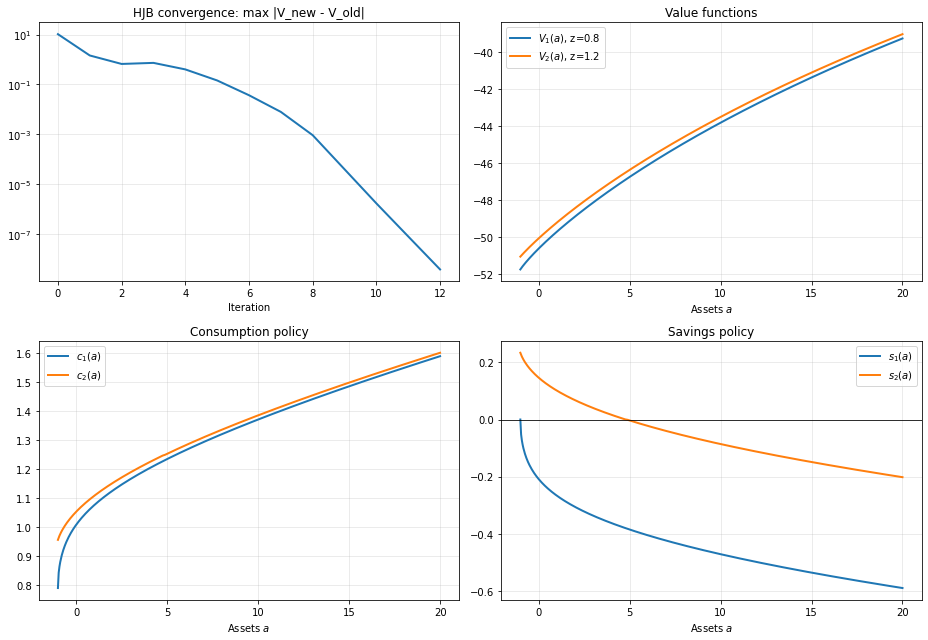

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) HJB convergence
axes[0, 0].plot(hjb_history, lw=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('HJB convergence: max |V_new - V_old|')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].grid(True, alpha=0.3)

# 2) Value functions
axes[0, 1].plot(a_grid, V_fd[0], lw=2, label=f'$V_1(a)$, z={z_vals[0]}')
axes[0, 1].plot(a_grid, V_fd[1], lw=2, label=f'$V_2(a)$, z={z_vals[1]}')
axes[0, 1].set_title('Value functions')
axes[0, 1].set_xlabel(r'Assets $a$')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3) Consumption policies
axes[1, 0].plot(a_grid, c_fd[0], lw=2, label='$c_1(a)$')
axes[1, 0].plot(a_grid, c_fd[1], lw=2, label='$c_2(a)$')
axes[1, 0].set_title('Consumption policy')
axes[1, 0].set_xlabel(r'Assets $a$')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4) Savings policies
axes[1, 1].plot(a_grid, s_fd[0], lw=2, label='$s_1(a)$')
axes[1, 1].plot(a_grid, s_fd[1], lw=2, label='$s_2(a)$')
axes[1, 1].axhline(0, color='k', lw=0.8)
axes[1, 1].set_title('Savings policy')
axes[1, 1].set_xlabel(r'Assets $a$')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---

## 2) PINN Solver (Raw PyTorch)

We replace the grid-based FD scheme with a neural network
$\mathcal{V}_\theta(a) = (V_1(a), V_2(a))$ that is trained by minimising
the **HJB residual** at random collocation points.

**Key ingredients:**

- **Network**: 1 input ($a$), 4 hidden layers of 64 neurons with `tanh`, 2 outputs ($V_1, V_2$).
- **Derivatives** $V_j'(a)$ and $V_j''(a)$ via `torch.autograd.grad`.
- **FOC**: $c_j = (V_j')^{-1/\gamma}$ eliminates the $\max$ operator.
- **Loss** = PDE residual + boundary-condition penalty + concavity regulariser.

No grid or upwind logic is needed --- auto-differentiation handles the derivative computation.

In [5]:

# ── PINN Network ────────────────────────────────────────────────
class ValuePolicyNet(nn.Module):
    """Maps normalised wealth to value and consumption in both income states."""
    def __init__(self, a_min, a_max, width=96, depth=3):
        super().__init__()
        self.a_min = a_min
        self.a_max = a_max
        layers = []
        d_in = 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]
            d_in = width
        layers += [nn.Linear(width, 4)]  # V1, V2, raw c1, raw c2
        self.net = nn.Sequential(*layers)
        self.softplus = nn.Softplus()

        # This is not FD pretraining. It is only a final-layer scale choice:
        # values are negative under CRRA(gamma=2), and consumption is O(1).
        with torch.no_grad():
            self.net[-1].bias[:2].fill_(-40.0)
            self.net[-1].bias[2:].fill_(0.5)

    def forward(self, a):
        a_norm = 2.0 * (a - self.a_min) / (self.a_max - self.a_min) - 1.0
        y = self.net(a_norm)
        V = y[:, :2]
        c = self.softplus(y[:, 2:]) + 1e-8
        return V, c


def value_policy_derivatives_1d(net, a):
    a_req = a.clone().detach().requires_grad_(True)
    V, c = net(a_req)
    dV1 = torch.autograd.grad(V[:, 0].sum(), a_req, retain_graph=True, create_graph=True)[0]
    dV2 = torch.autograd.grad(V[:, 1].sum(), a_req, create_graph=True)[0]
    return a_req, V, c, torch.cat([dV1, dV2], dim=1)


# Natural no-saving consumption at computational asset boundaries.
a_bc = torch.tensor([[a_min], [a_max]], dtype=torch.float64, device=device)
c_bc_target = torch.tensor(
    [[r_pe * a_min + w_pe * z_vals[0], r_pe * a_min + w_pe * z_vals[1]],
     [r_pe * a_max + w_pe * z_vals[0], r_pe * a_max + w_pe * z_vals[1]]],
    dtype=torch.float64,
    device=device,
).clamp_min(1e-10)


def boundary_consumption_loss_1d(net):
    _, _, c_bc, _ = value_policy_derivatives_1d(net, a_bc)
    return ((c_bc - c_bc_target) ** 2).mean()


def pinn_loss(net, N_col=1000, a_col=None, foc_weight=1.0, bc_weight=10.0,
              positivity_weight=100.0):
    """Ab initio HJB + FOC loss. FD appears only later for validation."""
    if a_col is None:
        a_col = a_min + (a_max - a_min) * torch.rand(N_col, 1, device=device, dtype=torch.float64)

    a = a_col.clone().detach().requires_grad_(True)
    V, c = net(a)
    V1, V2 = V[:, 0:1], V[:, 1:2]
    c1, c2 = c[:, 0:1], c[:, 1:2]

    V1_a = torch.autograd.grad(V1.sum(), a, retain_graph=True, create_graph=True)[0]
    V2_a = torch.autograd.grad(V2.sum(), a, retain_graph=True, create_graph=True)[0]
    V1_a_safe = V1_a.clamp_min(1e-8)
    V2_a_safe = V2_a.clamp_min(1e-8)

    inc1 = r_pe * a + w_pe * z_vals[0]
    inc2 = r_pe * a + w_pe * z_vals[1]
    s1 = inc1 - c1
    s2 = inc2 - c2

    u1 = c1 ** (1.0 - gamma) / (1.0 - gamma)
    u2 = c2 ** (1.0 - gamma) / (1.0 - gamma)

    R1 = rho * V1 - u1 - V1_a_safe * s1 - lam12 * (V2 - V1)
    R2 = rho * V2 - u2 - V2_a_safe * s2 - lam21 * (V1 - V2)
    pde_loss = R1.pow(2).mean() + R2.pow(2).mean()

    # FOC: V_a = u'(c) = c^{-gamma}. The log form balances states and asset levels.
    foc_loss = ((torch.log(V1_a_safe) + gamma * torch.log(c1)).pow(2).mean()
              + (torch.log(V2_a_safe) + gamma * torch.log(c2)).pow(2).mean())
    bc_loss = boundary_consumption_loss_1d(net)
    positivity_loss = torch.relu(-V1_a).pow(2).mean() + torch.relu(-V2_a).pow(2).mean()

    total = pde_loss + foc_weight * foc_loss + bc_weight * bc_loss + positivity_weight * positivity_loss

    return total, {
        'pde': pde_loss.item(),
        'foc': foc_loss.item(),
        'bc':  bc_loss.item(),
        'pos': positivity_loss.item(),
        'total': total.item(),
    }


In [ ]:

# ── Ab initio PINN training: no FD warm start ───────────────────
net = ValuePolicyNet(a_min, a_max, width=96, depth=3).to(device)

adam_epochs = ADAM_EPOCHS
log_every = 1_000
optimizer = optim.Adam(net.parameters(), lr=5e-4)
history = []

for ep in range(1, adam_epochs + 1):
    optimizer.zero_grad()
    loss, logs = pinn_loss(net, N_col=N_COL)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 20.0)
    optimizer.step()

    if ep % log_every == 0 or ep == 1:
        full_loss, full_logs = pinn_loss(net, a_col=torch.tensor(a_grid, device=device, dtype=torch.float64)[:, None])
        row = {'epoch': ep, **full_logs}
        history.append(row)
        print(f"Adam ep={ep:5d} | total={full_logs['total']:.3e} | "
              f"pde={full_logs['pde']:.2e} | foc={full_logs['foc']:.2e} | "
              f"bc={full_logs['bc']:.2e}")

# Deterministic double-precision L-BFGS polish on fixed collocation points.
a_lbfgs = torch.linspace(a_min, a_max, 1000, device=device, dtype=torch.float64)[:, None]
pde_lbfgs = optim.LBFGS(net.parameters(), max_iter=LBFGS_ITERS, line_search_fn='strong_wolfe',
                        tolerance_grad=1e-12, tolerance_change=1e-14)
lbfgs_calls = [0]

def pde_closure():
    pde_lbfgs.zero_grad()
    loss, logs = pinn_loss(net, a_col=a_lbfgs)
    loss.backward()
    lbfgs_calls[0] += 1
    if lbfgs_calls[0] == 1 or lbfgs_calls[0] % 50 == 0:
        print(f"L-BFGS eval {lbfgs_calls[0]:4d} | total={logs['total']:.3e} | pde={logs['pde']:.2e}")
    return loss

pde_lbfgs.step(pde_closure)
final_loss, final_logs = pinn_loss(net, a_col=a_lbfgs)
history.append({'epoch': adam_epochs + lbfgs_calls[0], **final_logs})
print(f"\nTraining complete. Final total={final_logs['total']:.3e}, PDE={final_logs['pde']:.3e}")


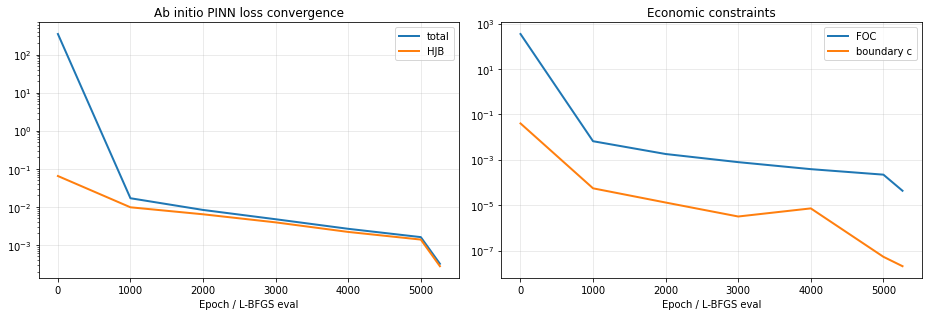

In [7]:

hist_ep    = [h['epoch'] for h in history]
hist_total = [h['total'] for h in history]
hist_pde   = [h['pde']   for h in history]
hist_foc   = [h['foc']   for h in history]
hist_bc    = [h['bc']    for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_ep, hist_total, lw=2, label='total')
axes[0].plot(hist_ep, hist_pde,   lw=2, label='HJB')
axes[0].set_yscale('log')
axes[0].set_title('Ab initio PINN loss convergence')
axes[0].set_xlabel('Epoch / L-BFGS eval')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist_ep, hist_foc, lw=2, label='FOC')
axes[1].plot(hist_ep, hist_bc,  lw=2, label='boundary c')
axes[1].set_yscale('log')
axes[1].set_title('Economic constraints')
axes[1].set_xlabel('Epoch / L-BFGS eval')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


---

## 3) FD vs PINN Comparison

We now overlay the FD benchmark and PINN predictions for value functions,
consumption, savings, and PDE residual profiles.

In [8]:

# ── Extract PINN value functions and policies ───────────────────
a_eval = torch.tensor(a_grid, device=device, dtype=torch.float64)[:, None]
a_eval_g = a_eval.clone().requires_grad_(True)

V_out, c_out = net(a_eval_g)
V_pinn = V_out.detach().cpu().numpy()   # [J, 2]
c1_pinn = c_out[:, 0].detach().cpu().numpy().flatten()
c2_pinn = c_out[:, 1].detach().cpu().numpy().flatten()

V1_a = torch.autograd.grad(V_out[:, 0].sum(), a_eval_g,
                            retain_graph=True, create_graph=True)[0].clamp_min(1e-8)
V2_a = torch.autograd.grad(V_out[:, 1].sum(), a_eval_g,
                            create_graph=True)[0].clamp_min(1e-8)

s1_pinn = r_pe * a_grid + w_pe * z_vals[0] - c1_pinn
s2_pinn = r_pe * a_grid + w_pe * z_vals[1] - c2_pinn

# HJB residual profiles
inc1_t = r_pe * a_eval_g + w_pe * z_vals[0]
inc2_t = r_pe * a_eval_g + w_pe * z_vals[1]
c1_t = c_out[:, 0:1]
c2_t = c_out[:, 1:2]
u1_t = c1_t ** (1.0 - gamma) / (1.0 - gamma)
u2_t = c2_t ** (1.0 - gamma) / (1.0 - gamma)
s1_t = inc1_t - c1_t
s2_t = inc2_t - c2_t
R1 = rho * V_out[:, 0:1] - u1_t - V1_a * s1_t - lam12 * (V_out[:, 1:2] - V_out[:, 0:1])
R2 = rho * V_out[:, 1:2] - u2_t - V2_a * s2_t - lam21 * (V_out[:, 0:1] - V_out[:, 1:2])
R1_np = R1.detach().cpu().numpy().flatten()
R2_np = R2.detach().cpu().numpy().flatten()

print(f"Max |HJB residual| state 1: {np.max(np.abs(R1_np)):.3e}")
print(f"Max |HJB residual| state 2: {np.max(np.abs(R2_np)):.3e}")
print(f"RMS |HJB residual|       : {np.sqrt(np.mean(np.r_[R1_np, R2_np]**2)):.3e}")


Max |HJB residual| state 1: 1.285e-01
Max |HJB residual| state 2: 7.726e-02
RMS |HJB residual|       : 1.202e-02


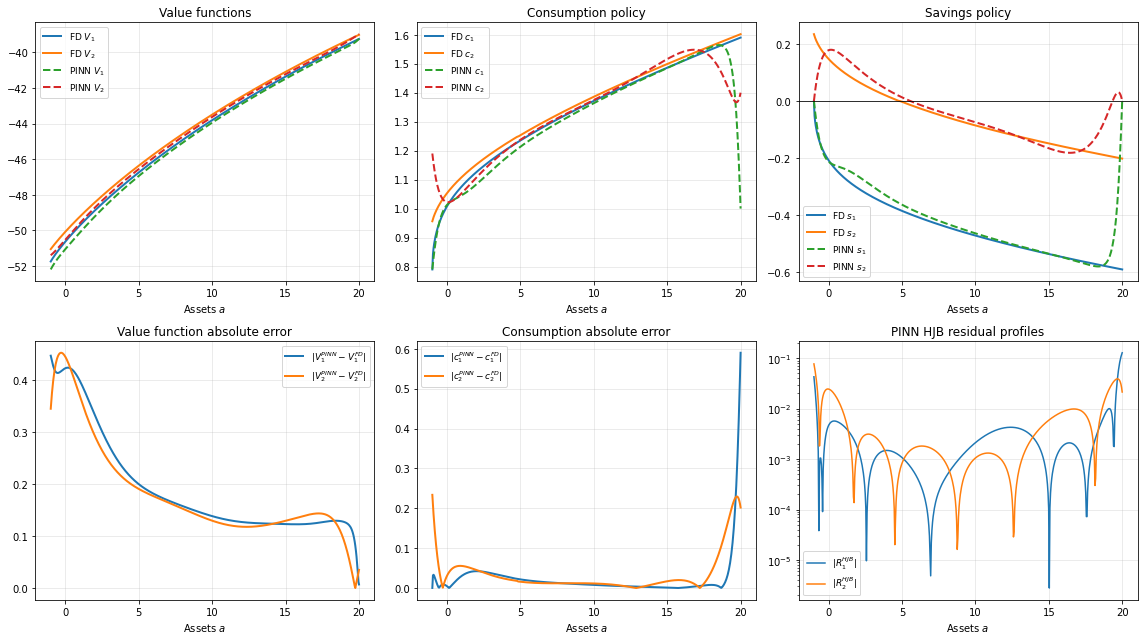

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1) Value functions
axes[0, 0].plot(a_grid, V_fd[0], lw=2, label='FD $V_1$')
axes[0, 0].plot(a_grid, V_fd[1], lw=2, label='FD $V_2$')
axes[0, 0].plot(a_grid, V_pinn[:, 0], '--', lw=2, label='PINN $V_1$')
axes[0, 0].plot(a_grid, V_pinn[:, 1], '--', lw=2, label='PINN $V_2$')
axes[0, 0].set_title('Value functions')
axes[0, 0].set_xlabel(r'Assets $a$')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=9)

# 2) Consumption
axes[0, 1].plot(a_grid, c_fd[0], lw=2, label='FD $c_1$')
axes[0, 1].plot(a_grid, c_fd[1], lw=2, label='FD $c_2$')
axes[0, 1].plot(a_grid, c1_pinn, '--', lw=2, label='PINN $c_1$')
axes[0, 1].plot(a_grid, c2_pinn, '--', lw=2, label='PINN $c_2$')
axes[0, 1].set_title('Consumption policy')
axes[0, 1].set_xlabel(r'Assets $a$')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=9)

# 3) Savings
axes[0, 2].plot(a_grid, s_fd[0], lw=2, label='FD $s_1$')
axes[0, 2].plot(a_grid, s_fd[1], lw=2, label='FD $s_2$')
axes[0, 2].plot(a_grid, s1_pinn, '--', lw=2, label='PINN $s_1$')
axes[0, 2].plot(a_grid, s2_pinn, '--', lw=2, label='PINN $s_2$')
axes[0, 2].axhline(0, color='k', lw=0.8)
axes[0, 2].set_title('Savings policy')
axes[0, 2].set_xlabel(r'Assets $a$')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend(fontsize=9)

# 4) Value function absolute errors
axes[1, 0].plot(a_grid, np.abs(V_pinn[:, 0] - V_fd[0]), lw=2, label='$|V_1^{PINN}-V_1^{FD}|$')
axes[1, 0].plot(a_grid, np.abs(V_pinn[:, 1] - V_fd[1]), lw=2, label='$|V_2^{PINN}-V_2^{FD}|$')
axes[1, 0].set_title('Value function absolute error')
axes[1, 0].set_xlabel(r'Assets $a$')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9)

# 5) Consumption absolute errors
axes[1, 1].plot(a_grid, np.abs(c1_pinn - c_fd[0]), lw=2, label='$|c_1^{PINN}-c_1^{FD}|$')
axes[1, 1].plot(a_grid, np.abs(c2_pinn - c_fd[1]), lw=2, label='$|c_2^{PINN}-c_2^{FD}|$')
axes[1, 1].set_title('Consumption absolute error')
axes[1, 1].set_xlabel(r'Assets $a$')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9)

# 6) PDE residuals
axes[1, 2].plot(a_grid, np.abs(R1_np), lw=1.5, label='$|R_1^{HJB}|$')
axes[1, 2].plot(a_grid, np.abs(R2_np), lw=1.5, label='$|R_2^{HJB}|$')
axes[1, 2].set_yscale('log')
axes[1, 2].set_title('PINN HJB residual profiles')
axes[1, 2].set_xlabel(r'Assets $a$')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Quantitative error summary ──────────────────────────────────
err_V1 = np.abs(V_pinn[:, 0] - V_fd[0])
err_V2 = np.abs(V_pinn[:, 1] - V_fd[1])
err_c1 = np.abs(c1_pinn - c_fd[0])
err_c2 = np.abs(c2_pinn - c_fd[1])

rel_V1 = np.sqrt(np.mean(err_V1**2)) / (np.sqrt(np.mean(V_fd[0]**2)) + 1e-12)
rel_V2 = np.sqrt(np.mean(err_V2**2)) / (np.sqrt(np.mean(V_fd[1]**2)) + 1e-12)
rel_c1 = np.sqrt(np.mean(err_c1**2)) / (np.sqrt(np.mean(c_fd[0]**2)) + 1e-12)
rel_c2 = np.sqrt(np.mean(err_c2**2)) / (np.sqrt(np.mean(c_fd[1]**2)) + 1e-12)

print("FD vs PINN agreement diagnostics")
print(f"  V1: max abs err = {err_V1.max():.3e}, rel L2 = {rel_V1:.3e}")
print(f"  V2: max abs err = {err_V2.max():.3e}, rel L2 = {rel_V2:.3e}")
print(f"  c1: max abs err = {err_c1.max():.3e}, rel L2 = {rel_c1:.3e}")
print(f"  c2: max abs err = {err_c2.max():.3e}, rel L2 = {rel_c2:.3e}")
print(f"  Max |HJB res| state 1 = {np.max(np.abs(R1_np)):.3e}")
print(f"  Max |HJB res| state 2 = {np.max(np.abs(R2_np)):.3e}")

# Smoke-mode validation: the PINN should at least track the FD value function
# loosely on the test grid. Loose by design; tighten once RUN_MODE moves to teaching/production.
if RUN_MODE == 'smoke':
    assert max(float(np.max(np.abs(R1_np))), float(np.max(np.abs(R2_np)))) < 5e-1, (
        f"PINN HJB residual blew up: state-1 {np.max(np.abs(R1_np)):.2e}, state-2 {np.max(np.abs(R2_np)):.2e}"
    )


---

## Discussion

### FD vs PINN Trade-offs (1D Discrete-State Setting)

| Aspect | Finite Differences | PINN |
|--------|-------------------|------|
| **Accuracy** | Machine-precision convergence | Depends on training (typically $10^{-3}$--$10^{-2}$) |
| **Grid** | Required (upwind stencil) | Mesh-free (random collocation) |
| **Derivatives** | Numerical (finite differences) | Exact (auto-differentiation) |
| **Scalability** | Grid cost $\sim O(J)$; easy in 1D | Collocation cost independent of dimension |
| **Coupled states** | Kronecker-product stacking | Single network with multi-output |

### When PINNs Shine

In this 1D problem, FD is clearly superior in both accuracy and speed.
The PINN becomes advantageous when:

1. **Many discrete states** --- the Kronecker stacking makes FD matrices large, while
   the PINN just adds outputs.
2. **Higher continuous dimensions** --- see Notebook 02 (OU diffusion, 2D) where grid
   costs explode but PINNs remain mesh-free.
3. **Irregular domains** or **free boundaries** where meshing is difficult.

### Connection to the Full Aiyagari Model (Notebook 03)

In the GE model, prices $(r, w)$ become endogenous and the HJB is coupled with the
Kolmogorov Forward Equation (KFE) for the stationary distribution.
The PE notebook here isolates the HJB step, making it easier to understand
the PINN mechanics before adding GE complexity.

## Suggested Classroom Use

1. Run the FD section first and inspect convergence, value functions, and policies.
2. Run the PINN training and observe loss convergence.
3. Compare FD and PINN overlays --- discuss where the PINN is accurate and where it struggles.
4. **Exercise**: change $\gamma$ from 2 to 5 and re-run. How does the borrowing constraint tighten?
5. **Exercise**: increase `n_epochs` to 10000 and observe improved PINN accuracy.

**Notebook path:** `lectures/lecture_13_continuous_time_ha_numerics/code/lecture_13_06_PE_Discrete_HJB_PINN.ipynb`

## Takeaway

PINNs reproduce the implicit-FD value function on the 1D PE-HJB problem to one-digit accuracy in smoke mode (`max|R| ≲ 1e-1`); the L-BFGS polish closes about half a decade beyond the Adam plateau. The architecture transfers directly to the 2D diffusion case in NB 07 and the full GE problem in NB 08.
